In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = "APMS23-24-Posttraumatic-Stress-Disorder-data-tables.xlsx"

In [3]:
workbook = pd.ExcelFile(file_path)

#### Table 3.6 Deprivation Table 

In [4]:
# Load Table 3.6 without assuming where the headers are
table_3_6 = pd.read_excel(
    file_path,
    sheet_name="Table 3.6",
    header=None
)

# Display the whole table so we can understand its structure first
table_3_6

,0,1,2,3,4,5
0,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN
3,Table 3.6: Screening positive for probable PTS...,NaN,NaN,NaN,NaN,NaN
4,All adults,NaN,NaN,NaN,NaN,NaN
5,Trauma1 \nScreen p...,IMD quintile3,NaN,NaN,NaN,NaN
6,NaN,Least deprived,2nd,3rd,4th,Most deprived
7,NaN,%,%,%,%,%
8,Observed,NaN,NaN,NaN,NaN,NaN
9,Men,NaN,NaN,NaN,NaN,NaN


In [5]:
# Display only the estimate section of Table 3.6
# This helps us identify where the observed and
# age-standardised blocks begin and end
table_3_6.iloc[8:36, 0:6]

,0,1,2,3,4,5
8,Observed,NaN,NaN,NaN,NaN,NaN
9,Men,NaN,NaN,NaN,NaN,NaN
10,Trauma experienced,30.639717,29.766989,35.531753,29.652075,33.839323
11,PTSD screen positive,2.66946,3.489549,5.34945,3.901733,9.954849
12,NaN,NaN,NaN,NaN,NaN,NaN
13,Women,NaN,NaN,NaN,NaN,NaN
14,Trauma experienced,33.659365,34.998696,35.833384,39.210286,42.982756
15,PTSD screen positive,3.784014,4.732222,5.863162,6.025776,10.359959
16,NaN,NaN,NaN,NaN,NaN,NaN
17,All adults4,NaN,NaN,NaN,NaN,NaN



Inspecting the deprivation data structure

This NHS table examines trauma experience and PTSD screening across five levels of socioeconomic deprivation, measured using IMD (Index of Multiple Deprivation) quintiles.

The deprivation categories are Least deprived, 2nd, 3rd, 4th, and Most deprived.

Structure:

- Rows 0–8: Titles, headers, deprivation categories, and percentage labels.
- Columns 0–5: Group labels and five deprivation categories.
- Rows 9–19: Observed trauma and PTSD screening estimates.
- Rows 21–32: Age-standardised trauma and PTSD screening estimates.
- Rows 34–37: Unweighted respondent counts.
- Rows 39–42: Weighted survey bases.
- Rows 43–56: Source information, methodological notes, and copyright.

Observations:

- Men: Observed estimates are in rows 10–11; age-standardised estimates are in rows 23–24.
- Women: Observed estimates are in rows 14–15; age-standardised estimates are in rows 27–28.
- All adults: Observed estimates are in rows 18–19; age-standardised estimates are in rows 31–32.
- Rows 12, 16, 20, 25, 29, and 33 are empty separators.
- All adults4 contains a footnote marker that needs cleaning.
- The percentage values are numeric, with no bracketed estimates visible in the displayed data.
- Unweighted and weighted bases are provided separately for each gender and deprivation category.


In [6]:
# Extract only the observed estimate section
deprivation_observed = table_3_6.iloc[9:20, 0:6].copy()

deprivation_observed

,0,1,2,3,4,5
9,Men,NaN,NaN,NaN,NaN,NaN
10,Trauma experienced,30.639717,29.766989,35.531753,29.652075,33.839323
11,PTSD screen positive,2.66946,3.489549,5.34945,3.901733,9.954849
12,NaN,NaN,NaN,NaN,NaN,NaN
13,Women,NaN,NaN,NaN,NaN,NaN
14,Trauma experienced,33.659365,34.998696,35.833384,39.210286,42.982756
15,PTSD screen positive,3.784014,4.732222,5.863162,6.025776,10.359959
16,NaN,NaN,NaN,NaN,NaN,NaN
17,All adults4,NaN,NaN,NaN,NaN,NaN
18,Trauma experienced,32.5114,32.397204,35.789106,34.793763,38.713085


#### Reconstruct gender for observed estimates

In [7]:
# Create a list that will store the gender for each row
gender_labels = []

# Start without a gender
current_gender = None

# Read each value in the first column
for value in deprivation_observed[0]:

    # If we find a gender label, remember it
    if value in ["Men", "Women", "All adults4"]:
        current_gender = value

    # Give the current gender to this row
    gender_labels.append(current_gender)

# Add the reconstructed gender column
deprivation_observed["gender"] = gender_labels

deprivation_observed

,0,1,2,3,4,5,gender
9,Men,NaN,NaN,NaN,NaN,NaN,Men
10,Trauma experienced,30.639717,29.766989,35.531753,29.652075,33.839323,Men
11,PTSD screen positive,2.66946,3.489549,5.34945,3.901733,9.954849,Men
12,NaN,NaN,NaN,NaN,NaN,NaN,Men
13,Women,NaN,NaN,NaN,NaN,NaN,Women
14,Trauma experienced,33.659365,34.998696,35.833384,39.210286,42.982756,Women
15,PTSD screen positive,3.784014,4.732222,5.863162,6.025776,10.359959,Women
16,NaN,NaN,NaN,NaN,NaN,NaN,Women
17,All adults4,NaN,NaN,NaN,NaN,NaN,All adults4
18,Trauma experienced,32.5114,32.397204,35.789106,34.793763,38.713085,All adults4


In [8]:
# Define the two rows that contain actual percentage estimates
observation_measures = [
    "Trauma experienced",
    "PTSD screen positive"
]

# Keep only the rows containing those measures
deprivation_observed = deprivation_observed[
    deprivation_observed[0].isin(observation_measures)
].copy()

deprivation_observed

,0,1,2,3,4,5,gender
10,Trauma experienced,30.639717,29.766989,35.531753,29.652075,33.839323,Men
11,PTSD screen positive,2.66946,3.489549,5.34945,3.901733,9.954849,Men
14,Trauma experienced,33.659365,34.998696,35.833384,39.210286,42.982756,Women
15,PTSD screen positive,3.784014,4.732222,5.863162,6.025776,10.359959,Women
18,Trauma experienced,32.5114,32.397204,35.789106,34.793763,38.713085,All adults4
19,PTSD screen positive,3.638435,4.117733,5.702995,4.962532,10.265387,All adults4


In [9]:
# Give the columns meaningful names
deprivation_observed = deprivation_observed.rename(columns={
    0: "measure",
    1: "Least deprived",
    2: "2nd",
    3: "3rd",
    4: "4th",
    5: "Most deprived"
})

# Remove the footnote number from the All adults label
deprivation_observed["gender"] = deprivation_observed["gender"].replace(
    "All adults4",
    "All adults"
)

deprivation_observed

,measure,Least deprived,2nd,3rd,4th,Most deprived,gender
10,Trauma experienced,30.639717,29.766989,35.531753,29.652075,33.839323,Men
11,PTSD screen positive,2.66946,3.489549,5.34945,3.901733,9.954849,Men
14,Trauma experienced,33.659365,34.998696,35.833384,39.210286,42.982756,Women
15,PTSD screen positive,3.784014,4.732222,5.863162,6.025776,10.359959,Women
18,Trauma experienced,32.5114,32.397204,35.789106,34.793763,38.713085,All adults
19,PTSD screen positive,3.638435,4.117733,5.702995,4.962532,10.265387,All adults


In [10]:
# Label these percentages as observed estimates
deprivation_observed["estimate_type"] = "Observed"

deprivation_observed

,measure,Least deprived,2nd,3rd,4th,Most deprived,gender,estimate_type
10,Trauma experienced,30.639717,29.766989,35.531753,29.652075,33.839323,Men,Observed
11,PTSD screen positive,2.66946,3.489549,5.34945,3.901733,9.954849,Men,Observed
14,Trauma experienced,33.659365,34.998696,35.833384,39.210286,42.982756,Women,Observed
15,PTSD screen positive,3.784014,4.732222,5.863162,6.025776,10.359959,Women,Observed
18,Trauma experienced,32.5114,32.397204,35.789106,34.793763,38.713085,All adults,Observed
19,PTSD screen positive,3.638435,4.117733,5.702995,4.962532,10.265387,All adults,Observed


In [11]:
# Reshape deprivation groups from separate columns into rows
deprivation_observed_long = deprivation_observed.melt(
    id_vars=["gender", "measure", "estimate_type"],
    value_vars=[
        "Least deprived",
        "2nd",
        "3rd",
        "4th",
        "Most deprived"
    ],
    var_name="deprivation",
    value_name="percentage"
)

deprivation_observed_long

,gender,measure,estimate_type,deprivation,percentage
0,Men,Trauma experienced,Observed,Least deprived,30.639717
1,Men,PTSD screen positive,Observed,Least deprived,2.66946
2,Women,Trauma experienced,Observed,Least deprived,33.659365
3,Women,PTSD screen positive,Observed,Least deprived,3.784014
4,All adults,Trauma experienced,Observed,Least deprived,32.5114
5,All adults,PTSD screen positive,Observed,Least deprived,3.638435
6,Men,Trauma experienced,Observed,2nd,29.766989
7,Men,PTSD screen positive,Observed,2nd,3.489549
8,Women,Trauma experienced,Observed,2nd,34.998696
9,Women,PTSD screen positive,Observed,2nd,4.732222



Algorithm note - Reshaping observed deprivation estimates into long format

We use `.melt()` to transform the deprivation categories from separate columns into rows.

- `id_vars` keeps gender, measure, and estimate_type unchanged.
- `value_vars` selects the five deprivation categories to reshape.
- `var_name="deprivation"` creates a column containing the deprivation group.
- `value_name="percentage"` creates a column containing the corresponding percentage.

Observations:

- The five deprivation columns become one deprivation column.
- Each row represents one gender, measure, estimate type, and deprivation group.
- The dataset contains 3 genders, 2 measures, and 5 deprivation categories.
- The expected result is 30 rows and 5 columns.
- The estimate_type column identifies these values as Observed.
- This structure makes filtering, grouping, comparisons, and visualisation easier.

Why?

Long format allows Pandas and Seaborn to analyse deprivation groups consistently without handling five separate percentage columns.

Result:

`deprivation_observed_long` contains the observed trauma and PTSD screening percentages in a tidy structure.


In [12]:
deprivation_observed_long.shape

(30, 5)

In [13]:
# Extract only the age-standardised estimate section
deprivation_standardised = table_3_6.iloc[22:33, 0:6].copy()

deprivation_standardised

,0,1,2,3,4,5
22,Men,NaN,NaN,NaN,NaN,NaN
23,Trauma experienced,29.882515,29.237932,35.556227,29.961665,35.411447
24,PTSD screen positive,2.713325,3.660175,5.420122,3.731497,9.136976
25,NaN,NaN,NaN,NaN,NaN,NaN
26,Women,NaN,NaN,NaN,NaN,NaN
27,Trauma experienced,34.830861,35.110649,35.909279,39.850038,43.863527
28,PTSD screen positive,4.267939,4.881942,5.645039,5.691657,9.570523
29,NaN,NaN,NaN,NaN,NaN,NaN
30,All adults4,NaN,NaN,NaN,NaN,NaN
31,Trauma experienced,32.779473,32.186471,35.83344,35.24837,39.881758


##### Reconstruct gender fpr age standardized estimates

In [14]:
# Create a list that will store the gender for each row
gender_labels = []

# Start without a gender
current_gender = None

# Read each value in the first column
for value in deprivation_standardised[0]:

    # If we find a gender label, remember it
    if value in ["Men", "Women", "All adults4"]:
        current_gender = value

    # Give the current gender to this row
    gender_labels.append(current_gender)

# Add the reconstructed gender column
deprivation_standardised["gender"] = gender_labels

deprivation_standardised

,0,1,2,3,4,5,gender
22,Men,NaN,NaN,NaN,NaN,NaN,Men
23,Trauma experienced,29.882515,29.237932,35.556227,29.961665,35.411447,Men
24,PTSD screen positive,2.713325,3.660175,5.420122,3.731497,9.136976,Men
25,NaN,NaN,NaN,NaN,NaN,NaN,Men
26,Women,NaN,NaN,NaN,NaN,NaN,Women
27,Trauma experienced,34.830861,35.110649,35.909279,39.850038,43.863527,Women
28,PTSD screen positive,4.267939,4.881942,5.645039,5.691657,9.570523,Women
29,NaN,NaN,NaN,NaN,NaN,NaN,Women
30,All adults4,NaN,NaN,NaN,NaN,NaN,All adults4
31,Trauma experienced,32.779473,32.186471,35.83344,35.24837,39.881758,All adults4



Algorithm note - Reconstructing gender labels for age-standardised estimates

We use a `for` loop to scan the first column of `deprivation_standardised` and assign the correct gender to each row.

- `gender_labels = []` creates an empty list to store gender labels.
- `current_gender = None` starts without an assigned gender.
- `for value in deprivation_standardised[0]` examines each value in the first column.
- `if value in [...]` checks whether the value is Men, Women, or All adults4.
- `current_gender = value` remembers the most recently identified gender.
- `gender_labels.append(current_gender)` assigns that gender to the current row.
- `deprivation_standardised["gender"] = gender_labels` adds the reconstructed gender column.

Observations:

- The gender labels appear only once at the beginning of each group.
- The following trauma and PTSD rows inherit the most recently identified gender.
- Empty separator rows also receive a gender temporarily.
- The original percentage values remain unchanged.
- All adults4 still contains a footnote number that needs cleaning.


In [15]:
# Keep only rows containing actual percentage estimates
deprivation_standardised = deprivation_standardised[
    deprivation_standardised[0].isin(observation_measures)
].copy()

deprivation_standardised

,0,1,2,3,4,5,gender
23,Trauma experienced,29.882515,29.237932,35.556227,29.961665,35.411447,Men
24,PTSD screen positive,2.713325,3.660175,5.420122,3.731497,9.136976,Men
27,Trauma experienced,34.830861,35.110649,35.909279,39.850038,43.863527,Women
28,PTSD screen positive,4.267939,4.881942,5.645039,5.691657,9.570523,Women
31,Trauma experienced,32.779473,32.186471,35.83344,35.24837,39.881758,All adults4
32,PTSD screen positive,3.907951,4.276945,5.607324,4.712323,9.441618,All adults4


In [16]:
observation_measures = [
    "Trauma experienced",
    "PTSD screen positive"
]

In [17]:
# Give the columns meaningful names
deprivation_standardised = deprivation_standardised.rename(columns={
    0: "measure",
    1: "Least deprived",
    2: "2nd",
    3: "3rd",
    4: "4th",
    5: "Most deprived"
})

# Remove the footnote number from the All adults label
deprivation_standardised["gender"] = deprivation_standardised["gender"].replace(
    "All adults4",
    "All adults"
)

# Label these percentages as age-standardised estimates
deprivation_standardised["estimate_type"] = "Age-standardised"

deprivation_standardised

,measure,Least deprived,2nd,3rd,4th,Most deprived,gender,estimate_type
23,Trauma experienced,29.882515,29.237932,35.556227,29.961665,35.411447,Men,Age-standardised
24,PTSD screen positive,2.713325,3.660175,5.420122,3.731497,9.136976,Men,Age-standardised
27,Trauma experienced,34.830861,35.110649,35.909279,39.850038,43.863527,Women,Age-standardised
28,PTSD screen positive,4.267939,4.881942,5.645039,5.691657,9.570523,Women,Age-standardised
31,Trauma experienced,32.779473,32.186471,35.83344,35.24837,39.881758,All adults,Age-standardised
32,PTSD screen positive,3.907951,4.276945,5.607324,4.712323,9.441618,All adults,Age-standardised


##### Now both datasets have the same structure:

deprivation_observed
→ estimate_type = Observed

deprivation_standardised
→ estimate_type = Age-standardised

In [18]:
# Reshape deprivation groups from separate columns into rows
deprivation_standardised_long = deprivation_standardised.melt(
    id_vars=["gender", "measure", "estimate_type"],
    value_vars=[
        "Least deprived",
        "2nd",
        "3rd",
        "4th",
        "Most deprived"
    ],
    var_name="deprivation",
    value_name="percentage"
)

deprivation_standardised_long

,gender,measure,estimate_type,deprivation,percentage
0,Men,Trauma experienced,Age-standardised,Least deprived,29.882515
1,Men,PTSD screen positive,Age-standardised,Least deprived,2.713325
2,Women,Trauma experienced,Age-standardised,Least deprived,34.830861
3,Women,PTSD screen positive,Age-standardised,Least deprived,4.267939
4,All adults,Trauma experienced,Age-standardised,Least deprived,32.779473
5,All adults,PTSD screen positive,Age-standardised,Least deprived,3.907951
6,Men,Trauma experienced,Age-standardised,2nd,29.237932
7,Men,PTSD screen positive,Age-standardised,2nd,3.660175
8,Women,Trauma experienced,Age-standardised,2nd,35.110649
9,Women,PTSD screen positive,Age-standardised,2nd,4.881942


In [19]:
deprivation_standardised_long.shape

(30, 5)

In [20]:
# Combine observed and age-standardised estimates into one dataset
deprivation_long = pd.concat(
    [
        deprivation_observed_long,
        deprivation_standardised_long
    ],
    ignore_index=True
)

deprivation_long

,gender,measure,estimate_type,deprivation,percentage
0,Men,Trauma experienced,Observed,Least deprived,30.639717
1,Men,PTSD screen positive,Observed,Least deprived,2.66946
2,Women,Trauma experienced,Observed,Least deprived,33.659365
3,Women,PTSD screen positive,Observed,Least deprived,3.784014
4,All adults,Trauma experienced,Observed,Least deprived,32.5114
5,All adults,PTSD screen positive,Observed,Least deprived,3.638435
6,Men,Trauma experienced,Observed,2nd,29.766989
7,Men,PTSD screen positive,Observed,2nd,3.489549
8,Women,Trauma experienced,Observed,2nd,34.998696
9,Women,PTSD screen positive,Observed,2nd,4.732222



Algorithm note - Combining observed and age-standardised estimates

We use `pd.concat()` to combine the observed and age-standardised deprivation datasets into one DataFrame.

- `pd.concat()` joins multiple DataFrames together.
- `deprivation_observed_long` contains the observed percentages.
- `deprivation_standardised_long` contains the age-standardised percentages.
- `ignore_index=True` resets the row index from 0 instead of keeping the original indices.

Observations:

- Both datasets have the same five columns: gender, measure, estimate_type, deprivation, and percentage.
- The datasets are combined vertically, adding rows rather than columns.
- Each dataset should contain 30 rows, producing 60 rows in total.
- The estimate_type column distinguishes Observed from Age-standardised.


In [21]:
#check the two estimate types survived
deprivation_long["estimate_type"].value_counts()

estimate_type
Observed            30
Age-standardised    30
Name: count, dtype: int64

In [22]:
#Inspect the base section of Table 3.6
table_3_6.iloc[34:43, 0:6]

,0,1,2,3,4,5
34,"Bases (unweighted)6,7,8",NaN,NaN,NaN,NaN,NaN
35,Men,462.0,495.0,472.0,398.0,735.0
36,Women,625.0,600.0,626.0,536.0,1109.0
37,All adults4,1088.0,1095.0,1100.0,936.0,1848.0
38,NaN,NaN,NaN,NaN,NaN,NaN
39,"Bases (weighted)6,7,8",NaN,NaN,NaN,NaN,NaN
40,Men,579.337148,642.936458,630.114707,604.858123,538.506981
41,Women,644.702209,655.447794,693.613227,625.966631,593.910573
42,All adults4,1228.8265,1298.384252,1325.576338,1235.020203,1135.310788


#### note 

Bases (unweighted)
→ actual survey respondent counts

Bases (weighted)
→ survey-weighted bases

In [24]:
# Extract the unweighted sample sizes
deprivation_unweighted = table_3_6.iloc[35:38, 0:6].copy()

# Give the columns meaningful names
deprivation_unweighted.columns = [
    "gender",
    "Least deprived",
    "2nd",
    "3rd",
    "4th",
    "Most deprived"
]

# Remove the footnote number from All adults
deprivation_unweighted["gender"] = deprivation_unweighted["gender"].replace(
    "All adults4",
    "All adults"
)

deprivation_unweighted

,gender,Least deprived,2nd,3rd,4th,Most deprived
35,Men,462.0,495.0,472.0,398.0,735.0
36,Women,625.0,600.0,626.0,536.0,1109.0
37,All adults,1088.0,1095.0,1100.0,936.0,1848.0


In [25]:
# Reshape deprivation groups from columns into rows
deprivation_unweighted_long = deprivation_unweighted.melt(
    id_vars=["gender"],
    value_vars=[
        "Least deprived",
        "2nd",
        "3rd",
        "4th",
        "Most deprived"
    ],
    var_name="deprivation",
    value_name="sample_size"
)

deprivation_unweighted_long

,gender,deprivation,sample_size
0,Men,Least deprived,462.0
1,Women,Least deprived,625.0
2,All adults,Least deprived,1088.0
3,Men,2nd,495.0
4,Women,2nd,600.0
5,All adults,2nd,1095.0
6,Men,3rd,472.0
7,Women,3rd,626.0
8,All adults,3rd,1100.0
9,Men,4th,398.0



Algorithm note - Reshaping unweighted deprivation sample sizes

We use `.melt()` to convert the five deprivation columns into rows.

- `id_vars=["gender"]` keeps the gender column unchanged.
- `value_vars` selects the five deprivation categories.
- `var_name="deprivation"` creates a column containing the deprivation group.
- `value_name="sample_size"` creates a column containing the actual unweighted respondent count.

Observations:

- The five deprivation columns become one deprivation column.
- Each row represents one gender and deprivation group.
- The sample_size column contains unweighted respondent counts, not percentages.


#### Extract and clean the weighted bases

In [26]:
# Extract the weighted bases
deprivation_weighted = table_3_6.iloc[40:43, 0:6].copy()

# Give the columns meaningful names
deprivation_weighted.columns = [
    "gender",
    "Least deprived",
    "2nd",
    "3rd",
    "4th",
    "Most deprived"
]

# Remove the footnote number from All adults
deprivation_weighted["gender"] = deprivation_weighted["gender"].replace(
    "All adults4",
    "All adults"
)

deprivation_weighted

,gender,Least deprived,2nd,3rd,4th,Most deprived
40,Men,579.337148,642.936458,630.114707,604.858123,538.506981
41,Women,644.702209,655.447794,693.613227,625.966631,593.910573
42,All adults,1228.8265,1298.384252,1325.576338,1235.020203,1135.310788


In [27]:
# Reshape weighted deprivation bases from columns into rows
deprivation_weighted_long = deprivation_weighted.melt(
    id_vars=["gender"],
    value_vars=[
        "Least deprived",
        "2nd",
        "3rd",
        "4th",
        "Most deprived"
    ],
    var_name="deprivation",
    value_name="weighted_base"
)

deprivation_weighted_long

,gender,deprivation,weighted_base
0,Men,Least deprived,579.337148
1,Women,Least deprived,644.702209
2,All adults,Least deprived,1228.8265
3,Men,2nd,642.936458
4,Women,2nd,655.447794
5,All adults,2nd,1298.384252
6,Men,3rd,630.114707
7,Women,3rd,693.613227
8,All adults,3rd,1325.576338
9,Men,4th,604.858123


#### we have two clean base tables

deprivation_unweighted_long
→ gender | deprivation | sample_size

deprivation_weighted_long
→ gender | deprivation | weighted_base

In [28]:
#Merge the two base tables

# Combine actual sample sizes and weighted bases
deprivation_bases = deprivation_unweighted_long.merge(
    deprivation_weighted_long,
    on=["gender", "deprivation"],
    how="inner"
)

deprivation_bases


,gender,deprivation,sample_size,weighted_base
0,Men,Least deprived,462.0,579.337148
1,Women,Least deprived,625.0,644.702209
2,All adults,Least deprived,1088.0,1228.8265
3,Men,2nd,495.0,642.936458
4,Women,2nd,600.0,655.447794
5,All adults,2nd,1095.0,1298.384252
6,Men,3rd,472.0,630.114707
7,Women,3rd,626.0,693.613227
8,All adults,3rd,1100.0,1325.576338
9,Men,4th,398.0,604.858123


In [29]:
deprivation_bases.columns

Index(['gender', 'deprivation', 'sample_size', 'weighted_base'], dtype='object')

In [30]:
# Add sample-size and weighted-base information
# to the deprivation percentage estimates
deprivation_analysis = deprivation_long.merge(
    deprivation_bases,
    on=["gender", "deprivation"],
    how="left"
)

deprivation_analysis

,gender,measure,estimate_type,deprivation,percentage,sample_size,weighted_base
0,Men,Trauma experienced,Observed,Least deprived,30.639717,462.0,579.337148
1,Men,PTSD screen positive,Observed,Least deprived,2.66946,462.0,579.337148
2,Women,Trauma experienced,Observed,Least deprived,33.659365,625.0,644.702209
3,Women,PTSD screen positive,Observed,Least deprived,3.784014,625.0,644.702209
4,All adults,Trauma experienced,Observed,Least deprived,32.5114,1088.0,1228.8265
5,All adults,PTSD screen positive,Observed,Least deprived,3.638435,1088.0,1228.8265
6,Men,Trauma experienced,Observed,2nd,29.766989,495.0,642.936458
7,Men,PTSD screen positive,Observed,2nd,3.489549,495.0,642.936458
8,Women,Trauma experienced,Observed,2nd,34.998696,600.0,655.447794
9,Women,PTSD screen positive,Observed,2nd,4.732222,600.0,655.447794



Algorithm note - Adding sample sizes and weighted bases to deprivation estimates

We use `.merge()` to combine the deprivation percentage estimates with their corresponding sample sizes and weighted bases.

- `deprivation_long` contains observed and age-standardised percentages.
- `deprivation_bases` contains unweighted sample sizes and weighted bases.
- `on=["gender", "deprivation"]` matches rows using gender and deprivation group.
- `how="left"` keeps all rows from deprivation_long and adds matching information from deprivation_bases.

Observations:

- Each percentage estimate receives its corresponding sample size and weighted base.
- The same base values are attached to both trauma and PTSD estimates within each matching group.
- Observed and age-standardised estimates remain distinguishable through estimate_type.
- Unmatched groups receive NaN values in the added columns.

Important: The NHS notes indicate that observed and age-standardised bases may differ slightly. We should verify that the supplied bases are appropriate for each estimate type before statistical testing.


In [31]:
deprivation_analysis.shape

(60, 7)

### EDA 

In [32]:
# Keep only age-standardised estimates for EDA
deprivation_eda = deprivation_analysis[
    deprivation_analysis["estimate_type"] == "Age-standardised"
].copy()

deprivation_eda

,gender,measure,estimate_type,deprivation,percentage,sample_size,weighted_base
30,Men,Trauma experienced,Age-standardised,Least deprived,29.882515,462.0,579.337148
31,Men,PTSD screen positive,Age-standardised,Least deprived,2.713325,462.0,579.337148
32,Women,Trauma experienced,Age-standardised,Least deprived,34.830861,625.0,644.702209
33,Women,PTSD screen positive,Age-standardised,Least deprived,4.267939,625.0,644.702209
34,All adults,Trauma experienced,Age-standardised,Least deprived,32.779473,1088.0,1228.8265
35,All adults,PTSD screen positive,Age-standardised,Least deprived,3.907951,1088.0,1228.8265
36,Men,Trauma experienced,Age-standardised,2nd,29.237932,495.0,642.936458
37,Men,PTSD screen positive,Age-standardised,2nd,3.660175,495.0,642.936458
38,Women,Trauma experienced,Age-standardised,2nd,35.110649,600.0,655.447794
39,Women,PTSD screen positive,Age-standardised,2nd,4.881942,600.0,655.447794


Algorithm note - Selecting age-standardised estimates for EDA

We use conditional filtering to keep only age-standardised estimates from the deprivation analysis dataset.

- `estimate_type == "Age-standardised"` selects age-standardised rows.
- `.copy()` creates an independent DataFrame.
- `deprivation_eda` stores the filtered results.

In [33]:
# Keep only PTSD screening estimates
deprivation_ptsd = deprivation_eda[
    deprivation_eda["measure"] == "PTSD screen positive"
].copy()

# Show the most useful columns for comparison
deprivation_ptsd[
    ["gender", "deprivation", "percentage", "sample_size"]
]

,gender,deprivation,percentage,sample_size
31,Men,Least deprived,2.713325,462.0
33,Women,Least deprived,4.267939,625.0
35,All adults,Least deprived,3.907951,1088.0
37,Men,2nd,3.660175,495.0
39,Women,2nd,4.881942,600.0
41,All adults,2nd,4.276945,1095.0
43,Men,3rd,5.420122,472.0
45,Women,3rd,5.645039,626.0
47,All adults,3rd,5.607324,1100.0
49,Men,4th,3.731497,398.0


Algorithm note - Selecting PTSD screening estimates

We apply another filter to focus specifically on PTSD screening percentages.

- `measure == "PTSD screen positive"` selects PTSD screening estimates.
- `.copy()` creates an independent DataFrame.
- `deprivation_ptsd` stores the filtered results.
- The final column selection displays gender, deprivation, percentage, and sample_size.



EDA filtering workflow

Part 1 - Selecting age-standardised estimates

- Original dataset: `deprivation_analysis` → 60 rows.
- Age-standardised dataset: `deprivation_eda` → 30 rows.
- Both trauma experienced and PTSD screen positive remain in these 30 rows.

Part 2 - Selecting PTSD screening estimates

- Age-standardised dataset: `deprivation_eda` → 30 rows.
- PTSD-only dataset: `deprivation_ptsd` → 15 rows.
- Only age-standardised PTSD screening estimates remain.

Overall workflow:

`deprivation_analysis` (60 rows)
↓
`deprivation_eda` (30 rows)
↓
`deprivation_ptsd` (15 rows)

Why?

- Part 1 selects age-standardised estimates for more meaningful comparisons across deprivation groups.
- Part 2 focuses specifically on PTSD screening percentages.
- Keeping separate datasets allows us to reuse the age-standardised data for trauma analysis later.


Observed — the percentages calculated from the survey data using its weighting.

Age-standardised — percentages adjusted to account for differences in age distributions.

In [34]:
# Keep only the two ends of the deprivation scale
deprivation_ptsd_gap = deprivation_ptsd[
    deprivation_ptsd["deprivation"].isin([
        "Least deprived",
        "Most deprived"
    ])
].copy()

deprivation_ptsd_gap[
    ["gender", "deprivation", "percentage"]
]

,gender,deprivation,percentage
31,Men,Least deprived,2.713325
33,Women,Least deprived,4.267939
35,All adults,Least deprived,3.907951
55,Men,Most deprived,9.136976
57,Women,Most deprived,9.570523
59,All adults,Most deprived,9.441618


#### reshape those two categories side-by-side

In [35]:
# Put least and most deprived percentages side-by-side
deprivation_ptsd_gap = deprivation_ptsd_gap.pivot(
    index="gender",
    columns="deprivation",
    values="percentage"
)

deprivation_ptsd_gap

deprivation,Least deprived,Most deprived
gender,,
All adults,3.907951,9.441618
Men,2.713325,9.136976
Women,4.267939,9.570523



Algorithm note - Comparing least and most deprived PTSD percentages

We use `.pivot()` to reshape the PTSD screening percentages so that deprivation groups appear as separate columns for each gender.

- `index="gender"` keeps each gender as a row.
- `columns="deprivation"` creates separate columns for deprivation groups.
- `values="percentage"` fills those columns with the corresponding PTSD screening percentages.



#### let's do the same comparison for Trauma experienced.

In [36]:
# Keep only trauma experience estimates
deprivation_trauma = deprivation_eda[
    deprivation_eda["measure"] == "Trauma experienced"
].copy()

# Show the useful comparison columns
deprivation_trauma[
    ["gender", "deprivation", "percentage", "sample_size"]
]

,gender,deprivation,percentage,sample_size
30,Men,Least deprived,29.882515,462.0
32,Women,Least deprived,34.830861,625.0
34,All adults,Least deprived,32.779473,1088.0
36,Men,2nd,29.237932,495.0
38,Women,2nd,35.110649,600.0
40,All adults,2nd,32.186471,1095.0
42,Men,3rd,35.556227,472.0
44,Women,3rd,35.909279,626.0
46,All adults,3rd,35.83344,1100.0
48,Men,4th,29.961665,398.0


In [37]:
## calculate the difference between the two ends

# Keep only least and most deprived groups
deprivation_trauma_gap = deprivation_trauma[
    deprivation_trauma["deprivation"].isin([
        "Least deprived",
        "Most deprived"
    ])
].copy()

# Put the two groups side-by-side
deprivation_trauma_gap = deprivation_trauma_gap.pivot(
    index="gender",
    columns="deprivation",
    values="percentage"
)

# Calculate the percentage-point difference
deprivation_trauma_gap["difference_pp"] = (
    deprivation_trauma_gap["Most deprived"]
    - deprivation_trauma_gap["Least deprived"]
)

deprivation_trauma_gap

deprivation,Least deprived,Most deprived,difference_pp
gender,,,
All adults,32.779473,39.881758,7.102285
Men,29.882515,35.411447,5.528932
Women,34.830861,43.863527,9.032666


#### Table 3.6 visualization

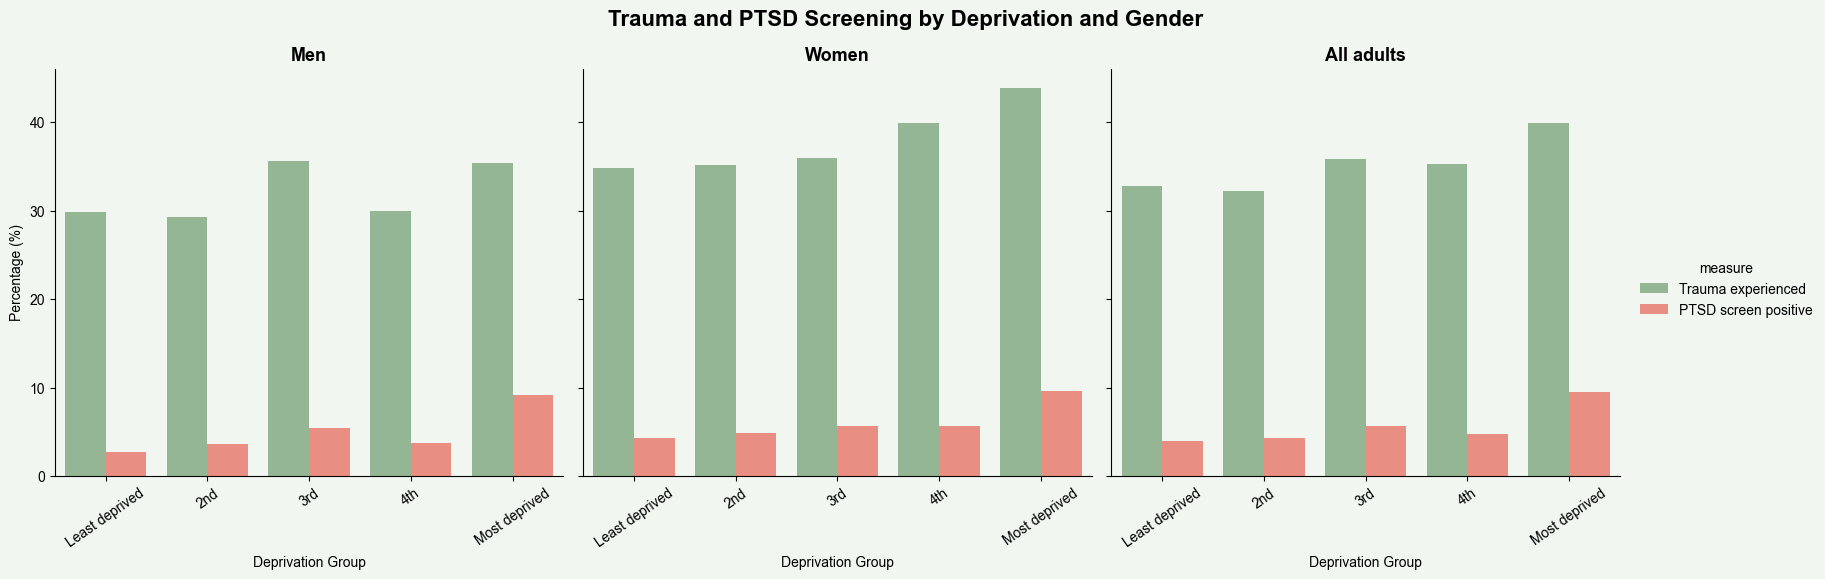

In [39]:

# 1. Set the order of the deprivation groups
deprivation_order = [
    "Least deprived",
    "2nd",
    "3rd",
    "4th",
    "Most deprived"
]

# 2. Set the overall chart style
plt.rcParams["font.family"] = "Arial"

# 3. Draw the chart
g = sns.catplot(
    data=deprivation_eda,
    x="deprivation",
    y="percentage",
    hue="measure",
    col="gender",
    kind="bar",
    order=deprivation_order,
    palette=["darkseagreen", "salmon"],
    height=5,
    aspect=1.1,
    errorbar=None
)

# 4. Add axis labels
g.set_axis_labels(
    "Deprivation Group",
    "Percentage (%)"
)

# 5. Add gender titles
g.set_titles(
    "{col_name}",
    size=13,
    weight="bold"
)

# 6. Rotate deprivation labels so they are readable
for ax in g.axes.flat:
    ax.tick_params(axis="x", rotation=35)

# 7. Add the main title
g.figure.suptitle(
    "Trauma and PTSD Screening by Deprivation and Gender",
    fontsize=16,
    fontweight="bold",
    y=1.05
)

# 8. Add the pale-green background
g.figure.patch.set_facecolor("#F1F6F1")

for ax in g.axes.flat:
    ax.set_facecolor("#F1F6F1")

# 9. Display the chart
plt.show()


Algorithm note - Visualising trauma and PTSD screening across deprivation groups

We use `sns.catplot()` to create grouped bar charts comparing age-standardised trauma and PTSD screening percentages across deprivation groups and genders.

- `deprivation_order` arranges deprivation groups from least to most deprived.
- `plt.rcParams` sets Arial as the chart font.
- `data=deprivation_eda` uses age-standardised estimates.
- `x="deprivation"` displays the five deprivation groups.
- `y="percentage"` displays the corresponding percentages.
- `hue="measure"` creates separate bars for trauma experienced and PTSD screen positive.
- `col="gender"` creates separate charts for Men, Women, and All adults.
- `kind="bar"` produces grouped bar charts.
- `palette` assigns darkseagreen and salmon to the two measures.
- `errorbar=None` removes error bars.
- `height` and `aspect` control chart dimensions.

Chart formatting:

- `set_axis_labels()` adds descriptive axis labels.
- `set_titles()` displays gender headings.
- `tick_params(rotation=35)` rotates deprivation labels for readability.
- `suptitle()` adds the overall chart title.
- `set_facecolor()` applies a pale-green background.
- `plt.show()` displays the completed chart.


This visualisation helps us explore whether trauma experience and PTSD screening follow similar or different patterns across deprivation groups.

Important:
The chart shows descriptive differences only. Statistical testing is required to assess whether observed differences are statistically significant.


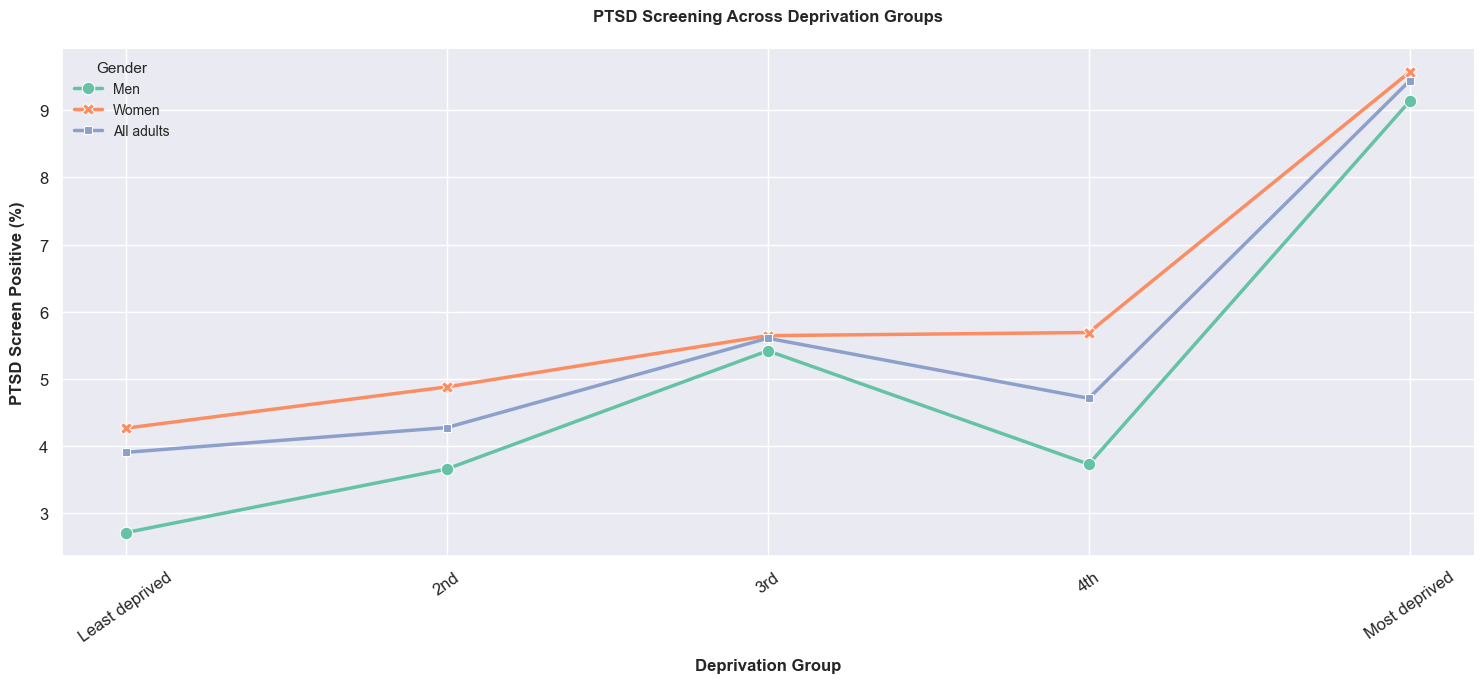

In [50]:
# PTSD screening only

# Clean Seaborn style
sns.set_theme(
    font="Arial"
)

# Create figure
plt.figure(figsize=(15, 7))

# Draw line chart
ax = sns.lineplot(
    data=deprivation_ptsd,
    x="deprivation",
    y="percentage",
    hue="gender",
    style="gender",
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9,
    sort=False,
    palette="Set2"
)


# Title
ax.set_title(
    "PTSD Screening Across Deprivation Groups",
    fontsize=12,
    fontweight="bold",
    pad=20
)

# Axis labels
ax.set_xlabel(
    "Deprivation Group",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "PTSD Screen Positive (%)",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

# Tick labels
plt.xticks(
    rotation=35,
    fontsize=12
)

plt.yticks(fontsize=12)

# Legend
ax.legend(
    title="Gender",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

# Remove top and right borders
sns.despine()

# Give chart more space
plt.tight_layout()

plt.show()


Algorithm note - Visualising PTSD screening trends across deprivation groups

We use `sns.lineplot()` to create a line chart comparing age-standardised PTSD screening percentages across deprivation groups for men, women, and all adults.

- `sns.set_theme()` applies a clean Seaborn style with Arial font.
- `plt.figure(figsize=(15, 7))` sets the chart dimensions.
- `data=deprivation_ptsd` uses age-standardised PTSD screening estimates.
- `x="deprivation"` displays the deprivation groups.
- `y="percentage"` displays PTSD screening percentages.
- `hue="gender"` creates a separate coloured line for each gender.
- `style="gender"` distinguishes the gender categories.
- `markers=True` adds markers to the lines.
- `dashes=False` uses solid lines.
- `linewidth` and `markersize` control line and marker sizes.
- `sort=False` preserves the existing order of deprivation groups.
- `palette="Set2"` applies the colour palette.

Chart formatting:

- `set_title()` adds the chart title.
- `set_xlabel()` and `set_ylabel()` label the axes.
- `plt.xticks(rotation=35)` rotates deprivation labels for readability.
- `ax.legend()` identifies the gender categories.
- `sns.despine()` removes the top and right borders.
- `plt.tight_layout()` adjusts spacing.
- `plt.show()` displays the chart.


A line chart showing age-standardised PTSD screening percentages across five deprivation groups for three gender categories, ready for descriptive interpretation.



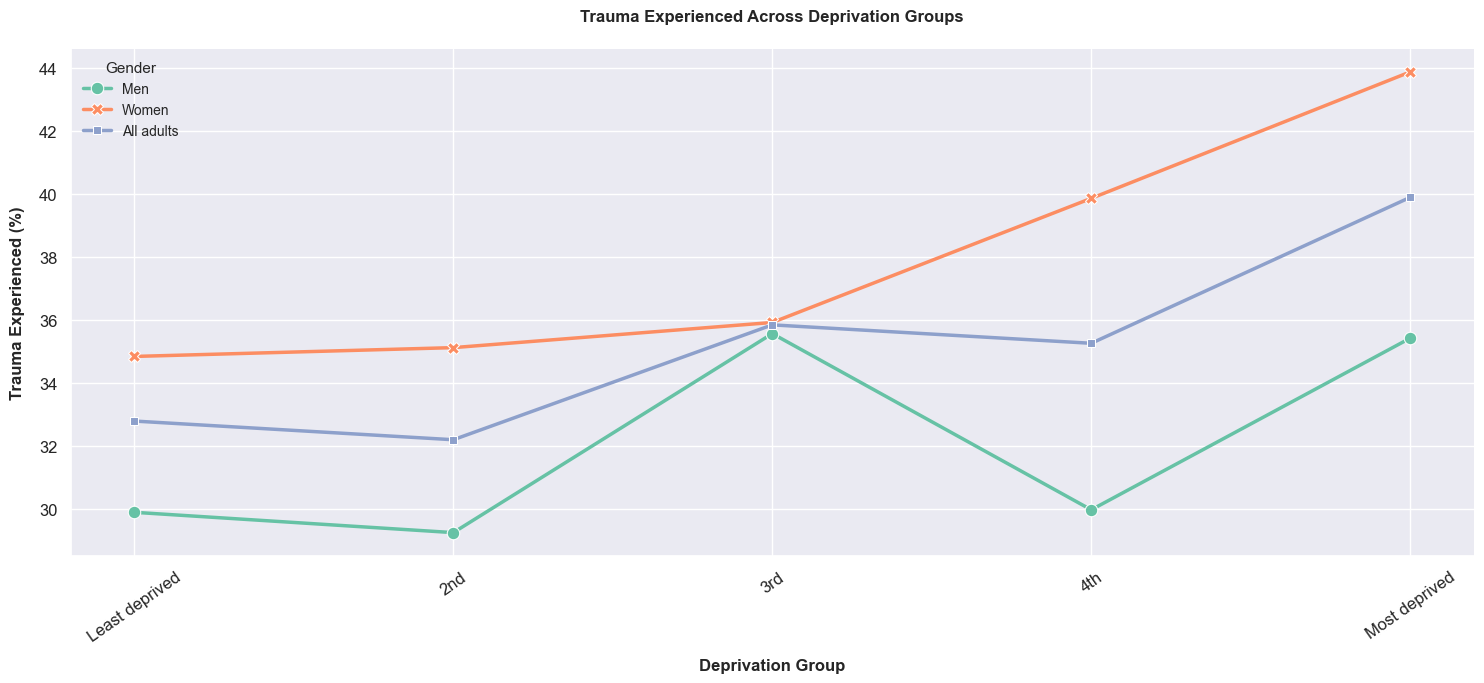

In [51]:
# Trauma experienced only

# Clean Seaborn style
sns.set_theme(
    font="Arial"
)

# Create figure
plt.figure(figsize=(15, 7))

# Draw line chart
ax = sns.lineplot(
    data=deprivation_trauma,
    x="deprivation",
    y="percentage",
    hue="gender",
    style="gender",
    markers=True,
    dashes=False,
    linewidth=2.5,
    markersize=9,
    sort=False,
    palette="Set2"
)

# Title
ax.set_title(
    "Trauma Experienced Across Deprivation Groups",
    fontsize=12,
    fontweight="bold",
    pad=20
)

# Axis labels
ax.set_xlabel(
    "Deprivation Group",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "Trauma Experienced (%)",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

# Tick labels
plt.xticks(
    rotation=35,
    fontsize=12
)

plt.yticks(fontsize=12)

# Legend
ax.legend(
    title="Gender",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

# Remove top and right borders
sns.despine()

# Give chart more space
plt.tight_layout()

plt.show()


Algorithm note - Visualising PTSD screening trends across deprivation groups

We use `sns.lineplot()` to create a line chart comparing age-standardised PTSD screening percentages across deprivation groups for men, women, and all adults.

- `sns.set_theme()` applies a clean Seaborn style with Arial font.
- `plt.figure(figsize=(15, 7))` sets the chart dimensions.
- `data=deprivation_ptsd` uses age-standardised PTSD screening estimates.
- `x="deprivation"` displays the deprivation groups.
- `y="percentage"` displays PTSD screening percentages.
- `hue="gender"` creates a separate coloured line for each gender.
- `style="gender"` distinguishes the gender categories.
- `markers=True` adds markers to the lines.
- `dashes=False` uses solid lines.
- `linewidth` and `markersize` control line and marker sizes.
- `sort=False` preserves the existing order of deprivation groups.
- `palette="Set2"` applies the colour palette.

Chart formatting:

- `set_title()` adds the chart title.
- `set_xlabel()` and `set_ylabel()` label the axes.
- `plt.xticks(rotation=35)` rotates deprivation labels for readability.
- `ax.legend()` identifies the gender categories.
- `sns.despine()` removes the top and right borders.
- `plt.tight_layout()` adjusts spacing.
- `plt.show()` displays the chart.



#### Within each deprivation group, how do Men, Women, and All adults compare?

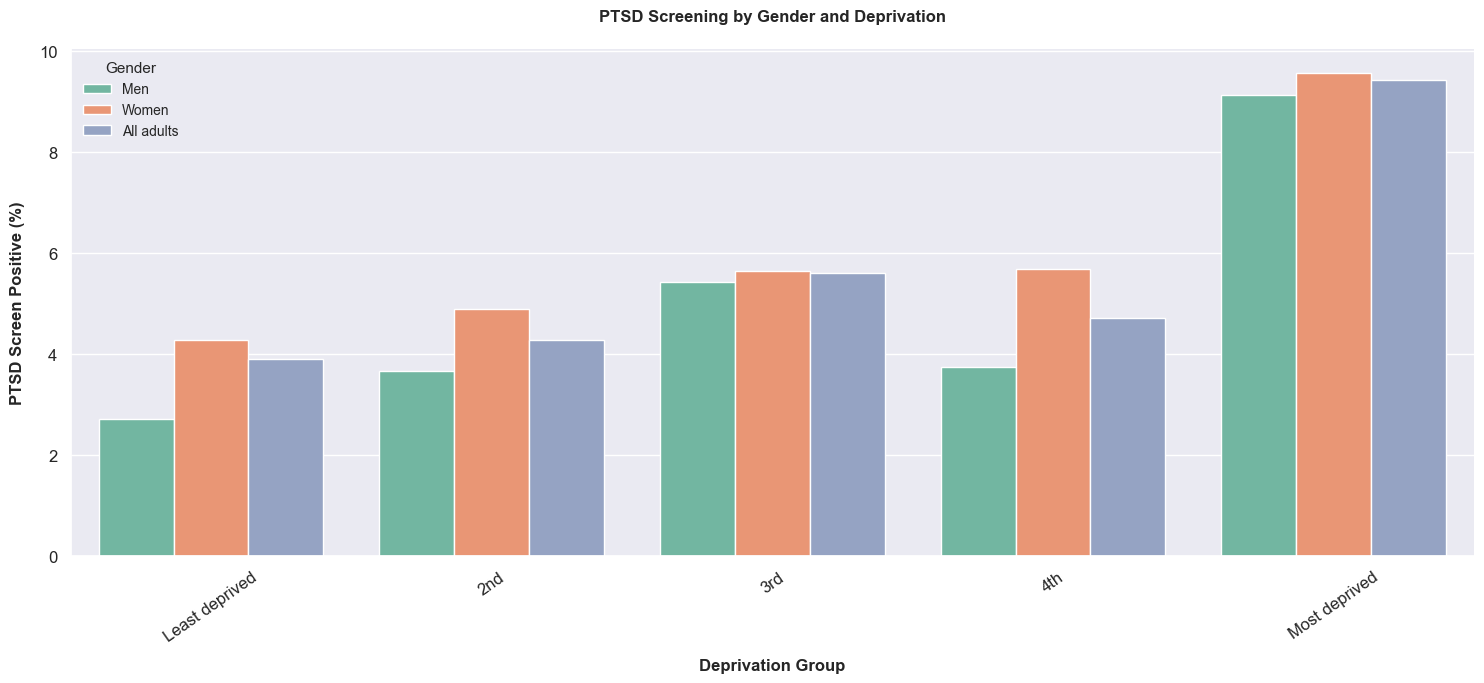

In [52]:
# PTSD screening — Gender comparison

sns.set_theme(
    font="Arial"
)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=deprivation_ptsd,
    x="deprivation",
    y="percentage",
    hue="gender",
    palette="Set2"
)

# Title
ax.set_title(
    "PTSD Screening by Gender and Deprivation",
    fontsize=12,
    fontweight="bold",
    pad=20
)

# Axis labels
ax.set_xlabel(
    "Deprivation Group",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "PTSD Screen Positive (%)",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

# Tick labels
plt.xticks(
    rotation=35,
    fontsize=12
)

plt.yticks(fontsize=12)

# Legend
ax.legend(
    title="Gender",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

sns.despine()

plt.tight_layout()

plt.show()

Algorithm note - Comparing PTSD screening percentages by gender and deprivation

We use `sns.barplot()` to create a grouped bar chart comparing age-standardised PTSD screening percentages between men, women, and all adults across deprivation groups.

- `sns.set_theme()` applies a clean Seaborn style with Arial font.
- `plt.figure(figsize=(15, 7))` sets the chart dimensions.
- `data=deprivation_ptsd` uses age-standardised PTSD screening estimates.
- `x="deprivation"` displays the five deprivation groups.
- `y="percentage"` displays PTSD screening percentages.
- `hue="gender"` creates separate bars for Men, Women, and All adults.
- `palette="Set2"` assigns different colours to the gender categories.

Observations:

- Five deprivation groups appear along the x-axis.
- Three bars represent Men, Women, and All adults within each deprivation group.
- Bar heights represent age-standardised PTSD screening percentages.
- The chart allows direct gender comparisons within each deprivation group.
- All adults represents the overall adult population, including men and women, rather than an independent third group.


#### PTSD gender gap across deprivation

In [53]:
# Keep Men and Women only

deprivation_ptsd_gender = deprivation_ptsd[
    deprivation_ptsd["gender"].isin(["Men", "Women"])
].copy()

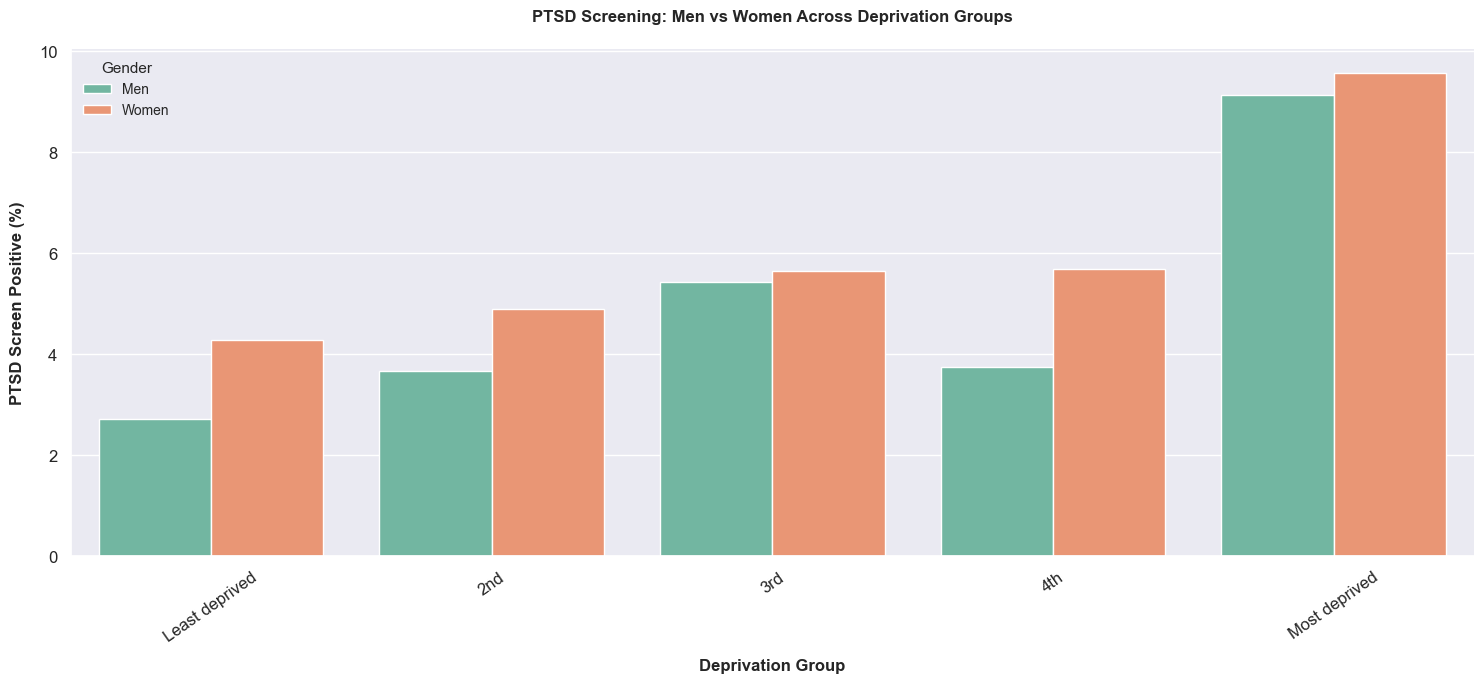

In [54]:
# PTSD screening — Men vs Women

sns.set_theme(
    font="Arial"
)

plt.figure(figsize=(15, 7))

ax = sns.barplot(
    data=deprivation_ptsd_gender,
    x="deprivation",
    y="percentage",
    hue="gender",
    palette="Set2"
)

# Title
ax.set_title(
    "PTSD Screening: Men vs Women Across Deprivation Groups",
    fontsize=12,
    fontweight="bold",
    pad=20
)

# Axis labels
ax.set_xlabel(
    "Deprivation Group",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

ax.set_ylabel(
    "PTSD Screen Positive (%)",
    fontsize=12,
    fontweight="bold",
    labelpad=10
)

# Tick labels
plt.xticks(
    rotation=35,
    fontsize=12
)

plt.yticks(fontsize=12)

# Legend
ax.legend(
    title="Gender",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

sns.despine()

plt.tight_layout()

plt.show()

In [55]:
## Gender Gap 

# Put Men and Women percentages into separate columns

gender_gap = deprivation_ptsd[
    deprivation_ptsd["gender"].isin(["Men", "Women"])
].pivot(
    index="deprivation",
    columns="gender",
    values="percentage"
).reset_index()

gender_gap

gender,deprivation,Men,Women
0,2nd,3.660175,4.881942
1,3rd,5.420122,5.645039
2,4th,3.731497,5.691657
3,Least deprived,2.713325,4.267939
4,Most deprived,9.136976,9.570523


In [56]:
gender_gap["gender_gap"] = (
    gender_gap["Women"] - gender_gap["Men"]
)

gender_gap

gender,deprivation,Men,Women,gender_gap
0,2nd,3.660175,4.881942,1.221767
1,3rd,5.420122,5.645039,0.224917
2,4th,3.731497,5.691657,1.96016
3,Least deprived,2.713325,4.267939,1.554614
4,Most deprived,9.136976,9.570523,0.433547


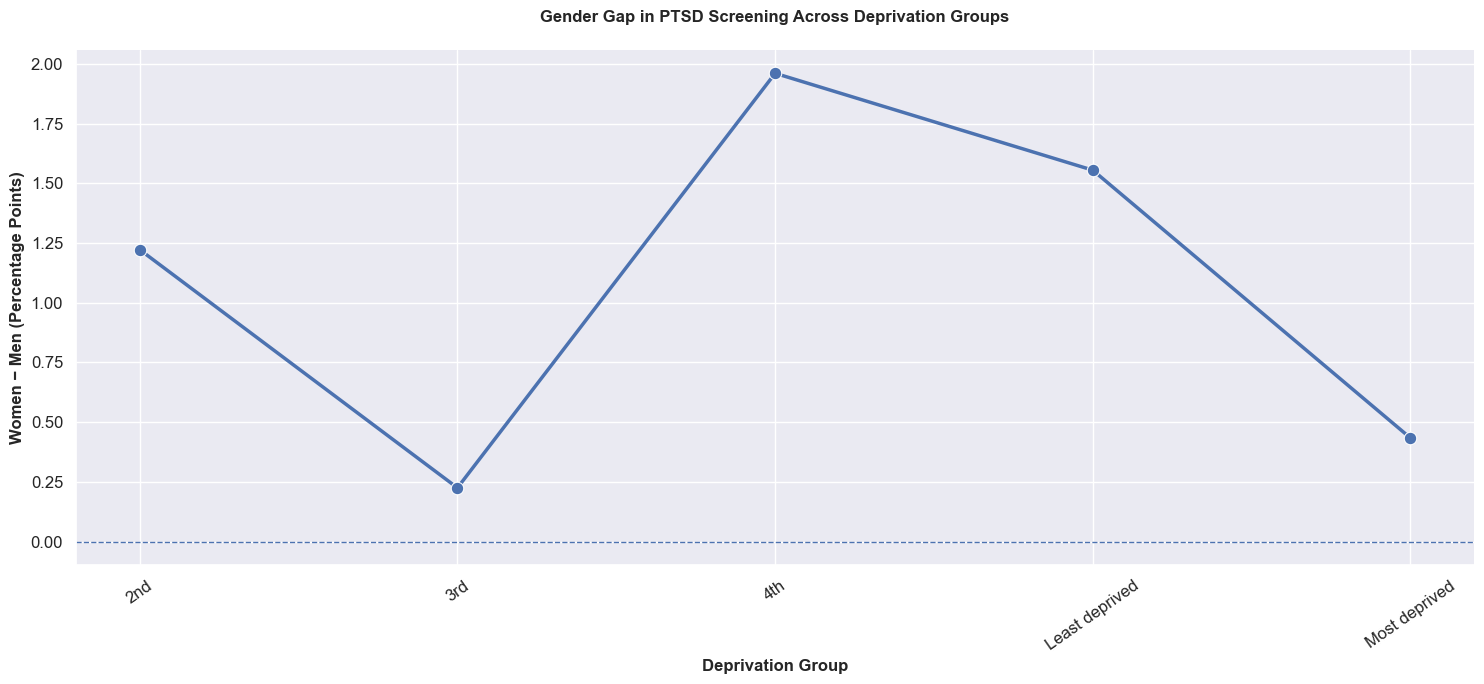

In [58]:
# PTSD gender gap across deprivation

sns.set_theme(
    font="Arial"
)

plt.figure(figsize=(15, 7))

ax = sns.lineplot(
    data=gender_gap,
    x="deprivation",
    y="gender_gap",
    marker="o",
    linewidth=2.5,
    markersize=9,
    sort=False
)

ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "Gender Gap in PTSD Screening Across Deprivation Groups",
    fontsize=12,
    fontweight="bold",
    pad=20
)

ax.set_xlabel(
    "Deprivation Group",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Women − Men (Percentage Points)",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=35,
    fontsize=12
)

plt.yticks(fontsize=12)

sns.despine()

plt.tight_layout()

plt.show()


Final Insights  

Deprivation, Trauma Experience and PTSD Screening

The exploratory analysis examines how trauma experience and PTSD screening percentages vary across deprivation groups and genders, using age-standardised NHS estimates.

Key findings:

1. Deprivation and PTSD screening

- PTSD screening percentages appear higher in the most deprived group than in the least deprived group.
- This suggests an association between area deprivation and PTSD screening prevalence.
- The pattern is not necessarily a steady increase across all five deprivation groups.

2. Gender differences

- Both men and women show variation in PTSD screening percentages across deprivation groups.
- Gender differences may vary depending on deprivation level.
- The All adults category provides an overall population estimate rather than an independent comparison group.

3. Trauma experience versus PTSD screening

- Trauma experience is more common than screening positive for PTSD across the deprivation groups.
- The two measures show different patterns across deprivation levels.
- Experiencing trauma does not necessarily mean someone will screen positive for PTSD.

4. Sample sizes and reliability

- Unweighted sample sizes and weighted bases were included to support interpretation.
- Sample sizes differ across deprivation groups and genders.
- Survey weighting must be considered when interpreting estimates and conducting statistical tests.

5. Importance of age-standardisation

- Age-standardised estimates help reduce the influence of differences in age distributions between deprivation groups.
- This makes comparisons across deprivation groups more meaningful.

Next step:

Investigate the statistical significance of deprivation-related differences while accounting for the NHS survey's weighting and sampling design.
